In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
! pip install plotly
import plotly.express as px


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
comments = pd.read_csv("data/raw/Uscomments.csv", on_bad_lines="skip")

C:\Users\DFIT\AppData\Local\Temp\ipykernel_5080\3282363696.py:1: DtypeWarning: Columns (0: likes, 1: replies) have mixed types. Specify dtype option on import or set low_memory=False.
  comments = pd.read_csv("data/raw/Uscomments.csv", on_bad_lines="skip")


In [10]:
comments

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0
...,...,...,...,...
691395,EoejGgUNmVU,Лучшая,1,0
691396,EoejGgUNmVU,qu'est ce que j'aimerais que tu viennes à Roan...,0,0
691397,EoejGgUNmVU,Ven a mexico! 😍 te amo LP,0,0
691398,EoejGgUNmVU,Islığı yeter...,0,0


In [11]:
comments.duplicated()


0         False
1         False
2         False
3         False
4         False
          ...  
691395     True
691396     True
691397     True
691398    False
691399     True
Length: 691400, dtype: bool

In [12]:
comments[comments.duplicated(keep=False)].sort_values("comment_text")

,video_id,comment_text,likes,replies
577043,xEqCt7GZo7M,,0,0
597655,xEqCt7GZo7M,,0,0
561617,uCVuyIQZ-lA,'Literally' 'like' my bestfriend\nCamila wut?🤔,0,0
581888,uCVuyIQZ-lA,'Literally' 'like' my bestfriend\nCamila wut?🤔,0,0
603266,uCVuyIQZ-lA,'Literally' 'like' my bestfriend\nCamila wut?🤔,0,0
...,...,...,...,...
563768,CX4KuIBmnjI,NaN,0,0
584612,CX4KuIBmnjI,NaN,0,0
605039,CX4KuIBmnjI,NaN,0,0
615625,5qlSfNVp3fU,NaN,0,0


In [13]:
comments = comments.drop_duplicates()

In [14]:
comments.isnull().sum()

video_id         0
comment_text    16
likes            0
replies          0
dtype: int64

In [15]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

In [16]:
comments.dropna(inplace = True)

In [17]:
comments.isnull().sum()


video_id        0
comment_text    0
likes           0
replies         0
dtype: int64

In [18]:
!pip install nltk
import nltk
nltk.download("vader_lexicon")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\DFIT\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [19]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [20]:
sia = SentimentIntensityAnalyzer()

In [22]:
comments["comment_text"]

0                         Logan Paul it's yo big day ‼️‼️‼️
1         I've been following you from the start of your...
2                        Say hi to Kong and maverick for me
3                                       MY FAN . attendance
4                                                trending 😉
                                ...                        
691359       Lost on you ! 😍\nOH My God I love this song !😭
691366                                        I  LOVE  LP❤️
691392                                *L O S T  O N  Y O U*
691393                                                   <3
691398                                      Islığı yeter...
Name: comment_text, Length: 478691, dtype: str

In [24]:
sia.polarity_scores(" MY FAN . attendance")["compound"]

0.4648

In [25]:
sia.lexicon

{'$:': -1.5,
 '%)': -0.4,
 '%-)': -1.5,
 '&-:': -0.4,
 '&:': -0.7,
 "( '}{' )": 1.6,
 '(%': -0.9,
 "('-:": 2.2,
 "(':": 2.3,
 '((-:': 2.1,
 '(*': 1.1,
 '(-%': -0.7,
 '(-*': 1.3,
 '(-:': 1.6,
 '(-:0': 2.8,
 '(-:<': -0.4,
 '(-:o': 1.5,
 '(-:O': 1.5,
 '(-:{': -0.1,
 '(-:|>*': 1.9,
 '(-;': 1.3,
 '(-;|': 2.1,
 '(8': 2.6,
 '(:': 2.2,
 '(:0': 2.4,
 '(:<': -0.2,
 '(:o': 2.5,
 '(:O': 2.5,
 '(;': 1.1,
 '(;<': 0.3,
 '(=': 2.2,
 '(?:': 2.1,
 '(^:': 1.5,
 '(^;': 1.5,
 '(^;0': 2.0,
 '(^;o': 1.9,
 '(o:': 1.6,
 ")':": -2.0,
 ")-':": -2.1,
 ')-:': -2.1,
 ')-:<': -2.2,
 ')-:{': -2.1,
 '):': -1.8,
 '):<': -1.9,
 '):{': -2.3,
 ');<': -2.6,
 '*)': 0.6,
 '*-)': 0.3,
 '*-:': 2.1,
 '*-;': 2.4,
 '*:': 1.9,
 '*<|:-)': 1.6,
 '*\\0/*': 2.3,
 '*^:': 1.6,
 ',-:': 1.2,
 "---'-;-{@": 2.3,
 '--<--<@': 2.2,
 '.-:': -1.2,
 '..###-:': -1.7,
 '..###:': -1.9,
 '/-:': -1.3,
 '/:': -1.3,
 '/:<': -1.4,
 '/=': -0.9,
 '/^:': -1.0,
 '/o:': -1.4,
 '0-8': 0.1,
 '0-|': -1.2,
 '0:)': 1.9,
 '0:-)': 1.4,
 '0:-3': 1.5,
 '0:03': 1.9,
 '

In [28]:
def analyze_comment_sentiment(comment):
    compound = sia.polarity_scores(comment)["compound"]

    if compound > 0.05:
        label = "Positive 😊"
        insight = "the comment expresses positive emotion or approval"

    elif compound < -0.05:
        label = "Negative 😡"
        insight = "the comment shows dis-satisfaction or negative emotion"

    else:
        label = "Neutral 😐"
        insight = "The comment is informational or emotionally neutral"

    return {
        "label": label,
        "score": compound,
        "insight": insight,
    }
    

In [30]:
analyze_comment_sentiment(" MY FAN . attendance")


{'label': 'Positive 😊',
 'socre': 0.4648,
 'insight': 'the comment expresses positive emotion or approval'}

In [31]:
!pip install emoji==2.15.0

   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/608.4 kB ? eta -:--:--
   -------------------------------- ----- 524.3/608.4 kB 344.7 kB/s eta 0:00:01
   ---------------------------------------- 608.4/608.4 kB 346.9 kB/s  0:00:01



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import emoji

In [33]:
comments["comment_text"].head(25)

0                     Logan Paul it's yo big day ‼️‼️‼️
1     I've been following you from the start of your...
2                    Say hi to Kong and maverick for me
3                                   MY FAN . attendance
4                                            trending 😉
5                               #1 on trending AYYEEEEE
6                                  The end though 😭👍🏻❤️
7                                  #1 trending!!!!!!!!!
8                           Happy one year vlogaversary
9     You and your shit brother may have single hand...
10               There should be a mini Logan Paul too!
11    Dear Logan, I really wanna get your Merch but ...
12    Honestly Evan is so annoying. Like its not fun...
13                     Casey is still better then logan
14        aw geez rick this guy is the face of YouTube.
15                         He happy cause he in a movie
16    Ayyyyoooo Logang what up .  This was a hard vl...
17    Bro y didnt u give merch to johannes he is

In [36]:
comment = "trending 😉"

In [37]:
emoji.EMOJI_DATA


{'🥇': {'en': ':1st_place_medal:', 'status': 2, 'E': 3},
 '🥈': {'en': ':2nd_place_medal:', 'status': 2, 'E': 3},
 '🥉': {'en': ':3rd_place_medal:', 'status': 2, 'E': 3},
 '🆎': {'en': ':AB_button_(blood_type):',
  'status': 2,
  'E': 0.6,
  'alias': [':ab:', ':ab_button_blood_type:']},
 '🏧': {'en': ':ATM_sign:',
  'status': 2,
  'E': 0.6,
  'alias': [':atm:', ':atm_sign:']},
 '🅰️': {'en': ':A_button_(blood_type):',
  'status': 2,
  'E': 0.6,
  'alias': [':a:', ':a_button_blood_type:'],
  'variant': True},
 '🅰': {'en': ':A_button_(blood_type):',
  'status': 4,
  'E': 0.6,
  'alias': [':a:', ':a_button_blood_type:'],
  'variant': True},
 '🇦🇫': {'en': ':Afghanistan:',
  'status': 2,
  'E': 2,
  'alias': [':flag_for_Afghanistan:', ':afghanistan:']},
 '🇦🇱': {'en': ':Albania:',
  'status': 2,
  'E': 2,
  'alias': [':flag_for_Albania:', ':albania:']},
 '🇩🇿': {'en': ':Algeria:',
  'status': 2,
  'E': 2,
  'alias': [':flag_for_Algeria:', ':algeria:']},
 '🇦🇸': {'en': ':American_Samoa:',
  'status':

In [38]:
emoji_list = []

for char in comment:
    if char in emoji.EMOJI_DATA:
        emoji_list.append(char)

In [39]:
emoji_list

['😉']

In [41]:
all_emojis_list = []
for comment in comments["comment_text"].dropna():
    for char in comment:
        if char in emoji.EMOJI_DATA:
            all_emojis_list.append(char)

In [42]:
all_emojis_list[0:20]

['‼',
 '‼',
 '‼',
 '😉',
 '😭',
 '👍',
 '🏻',
 '❤',
 '😍',
 '💋',
 '💙',
 '👍',
 '👈',
 '😂',
 '🔥',
 '😂',
 '😂',
 '😂',
 '😂',
 '👻']

In [43]:
len(all_emojis_list)

213868

In [44]:
from collections import Counter

In [45]:
emojis_count_list = Counter(all_emojis_list).most_common(10)

In [46]:
emojis_count_list

[('😂', 27287),
 ('❤', 22180),
 ('😍', 22145),
 ('🔥', 6288),
 ('😭', 6155),
 ('💖', 4242),
 ('😘', 4174),
 ('👏', 4005),
 ('👍', 3789),
 ('💕', 3731)]

In [48]:
emojis = [emoji for emoji,count in emojis_count_list]
emojis

['😂', '❤', '😍', '🔥', '😭', '💖', '😘', '👏', '👍', '💕']

In [49]:
counts = [count for emoji,count in emojis_count_list]
counts

[27287, 22180, 22145, 6288, 6155, 4242, 4174, 4005, 3789, 3731]

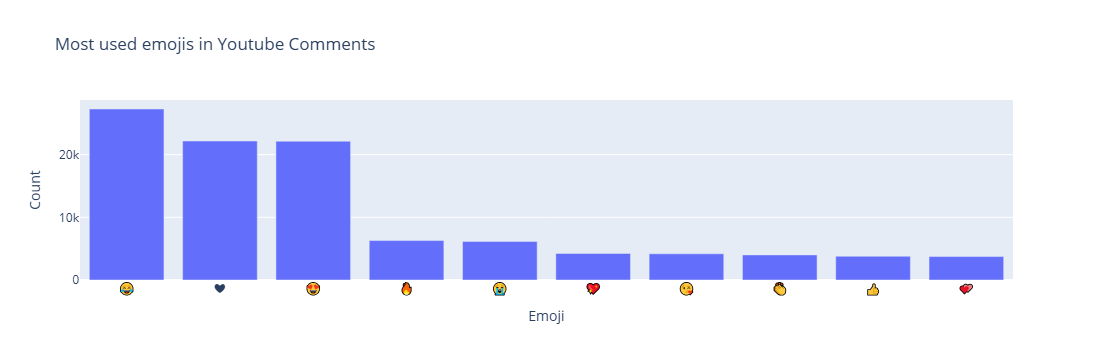

In [50]:
px.bar(x=emojis,y=counts,
      title ="Most used emojis in Youtube Comments",
      labels = {
          "x": "Emoji",
          "y": "Count"
      })

In [52]:
import os
files = os.listdir("data/raw/additional_data")
files

['CAvideos.csv',
 'CA_category_id.json',
 'DEvideos.csv',
 'DE_category_id.json',
 'FRvideos.csv',
 'FR_category_id.json',
 'GBvideos.csv',
 'GB_category_id.json',
 'INvideos.csv',
 'IN_category_id.json',
 'JPvideos.csv',
 'JP_category_id.json',
 'KRvideos.csv',
 'KR_category_id.json',
 'MXvideos.csv',
 'MX_category_id.json',
 'RUvideos.csv',
 'RU_category_id.json',
 'USvideos.csv',
 'US_category_id.json']

In [55]:
files_csv = [file for file in files if file.endswith(".csv")]

In [56]:
files_csv

['CAvideos.csv',
 'DEvideos.csv',
 'FRvideos.csv',
 'GBvideos.csv',
 'INvideos.csv',
 'JPvideos.csv',
 'KRvideos.csv',
 'MXvideos.csv',
 'RUvideos.csv',
 'USvideos.csv']

In [57]:
full_df = pd.DataFrame()

path = "data/raw/additional_data"

for file in files_csv:
    current_df = pd.read_csv(path + '/' + file, encoding="iso-8859-1", on_bad_lines="skip")
    full_df = pd.concat([current_df, full_df], ignore_index=True)

In [58]:
full_df.shape

(375942, 16)

In [59]:
full_df.head(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO â¶ \n\nSUBSCRIBE âº ...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...
